# Changing an outcome by adding voters

`03-LP.ipynb` built an electorate from nothing. This one starts from an
electorate that already exists and asks what it would take to change its mind:
the existing voters are fixed and counted, and the LP may only *add* more.

That turns every target into a price. `objective="min_total"` asks for the
cheapest way to install a given pair of winners, so a scan over all targets maps
what this electorate can be talked into, and at what cost.

In [1]:
import sys

sys.path.append("..")

from itertools import product

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

from voting import (
    BordaRule,
    Candidate,
    Election,
    LpModel,
    PluralityRule,
    Voter,
    mean_pairwise_distance,
    rule_for_key,
)
from voting.plotting import plot_election, plot_result

In [2]:
def verify_lp_winners(model, voter_positions):
    """Check that the generated voters really do elect the targets.

    The end-to-end check from `03-LP.ipynb`: the LP claims an electorate exists
    *in the plane*, so what settles it is running the positions through the
    ordinary `Election` pipeline. The fixed electorate is folded back in - it
    counts towards the tally but is not part of `generate_voter_positions()`.
    """
    base = [getattr(v, "position", v) for v in (model.voters or [])]
    election = Election(
        candidates=model.candidates,
        voters=[Voter(position=p) for p in [*base, *voter_positions]],
    )
    result = election.compare([rule_for_key(key) for key in model.winners])

    added = len(voter_positions)
    size_ok = (
        added == model.n_voters
        if model.n_voters is not None
        else added <= model.max_added
    )
    assert size_ok, f"LP returned {added} voters, breaking the size constraint"

    print(f"existing: {len(base)}, added: {added}")
    print()
    print(f"{'rule':<12} {'target':>7} {'actual':>7} {'margin':>8}")
    for key, target in model.winners.items():
        tally = result.tally(key)
        print(f"{key:<12} {target:>7} {tally.winner_index:>7} {tally.margin:>8g}")
        assert not tally.is_tie(), f"{key} is tied, so it has no winner"
        assert tally.winner_index == target, f"{key}: wanted {target}"

## The starting electorate

Voters clustered around the candidates in given proportions rather than spread uniformly.

In [3]:
def sample_voters(candidates, shares, total, sigma=1.0, seed=None):
    """Voters drawn from a Gaussian blob around each candidate.

    ``shares`` gives the percentage of the electorate in each candidate's blob,
    in candidate order.
    """
    if len(shares) != len(candidates):
        raise ValueError("shares must have the same length as candidates")

    rng = np.random.default_rng(seed)
    voters = []
    for candidate, share in zip(candidates, shares):
        x, y = candidate.position
        n = round(total * share / 100)
        xs = rng.normal(loc=x, scale=sigma, size=n)
        ys = rng.normal(loc=y, scale=sigma, size=n)
        voters.extend(Voter(position=np.array([vx, vy])) for vx, vy in zip(xs, ys))
    return voters

In [4]:
positions = [(-5, -5), (2, -3), (1, 2), (-2, 7), (7, 6)]
shares = [8.6, 30.7, 14.4, 35.4, 10.9]

candidates = [
    Candidate(id=id, position=position) for id, position in enumerate(positions)
]

N_VOTERS = 1000
N_CANDIDATES = len(candidates)
RULES = [PluralityRule(), BordaRule()]

natural outcome: {'plurality': 3, 'borda': 2}
tied: False, rules disagree: True


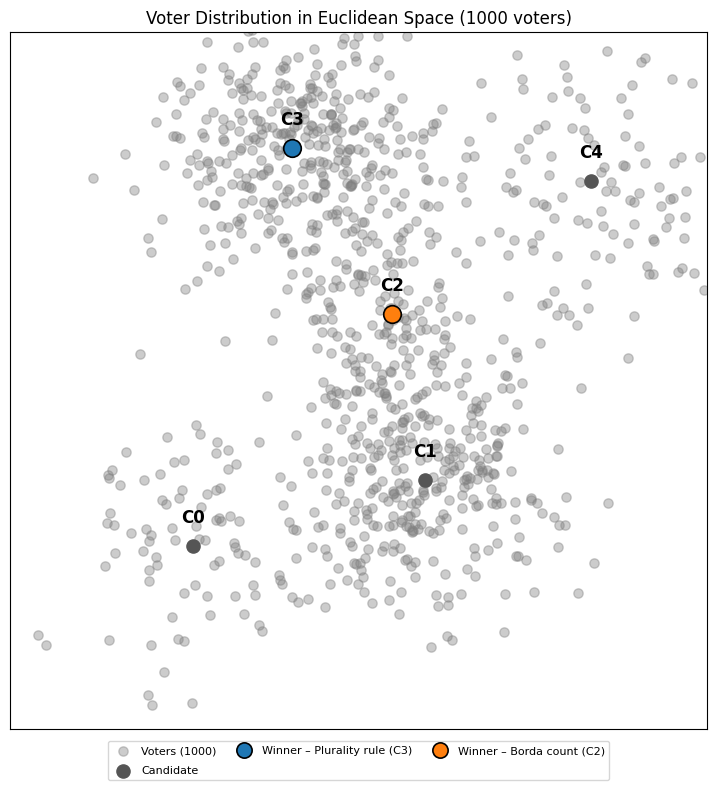

<Axes: title={'center': 'Voter Distribution in Euclidean Space (1000 voters)'}>

In [5]:
voters = sample_voters(candidates, shares, N_VOTERS, sigma=2.0, seed=0)
initial_result = Election(candidates=candidates, voters=voters).compare(RULES)

print(f"natural outcome: {initial_result.winner_indices()}")
print(f"tied: {initial_result.has_tie()}", end="")
print(f", rules disagree: {initial_result.rules_disagree()}")

plot_result(initial_result)

## Buying a different pair of winners

One target, four objectives. All four reach the same winners; what differs is
how the added voters are arranged and how much of the budget they spend.

`min_total` is the one that means something beyond arrangement - it is the price.

In [6]:
def run_swap(winners, objective="min_total", max_added=None):
    """Solve one swap model against the fixed electorate, then plot and verify.

    ``winners`` is a target dict, or a tuple aligned with ``RULES``.
    """
    if not isinstance(winners, dict):
        winners = dict(zip(RULES, winners))

    model = LpModel(
        candidates=candidates,
        base_voters=voters,
        max_added=max_added if max_added is not None else N_VOTERS,
        winners=winners,
        objective=objective,
    )
    status = model.solve()
    print(f"target {model.winners}, objective {objective!r} -> {status}")
    assert status == "Optimal"

    added = model.generate_voter_positions()
    existing = np.array([v.position for v in voters])
    plot_election(candidates, existing, model.winners, added_voters=added)
    verify_lp_winners(model, added)
    return model

In [7]:
# Rule objects work as keys directly; LpModel normalises them to rule keys.
winners = {PluralityRule: 3, BordaRule: 1}

target {'plurality': 3, 'borda': 1}, objective 'minmax' -> Optimal


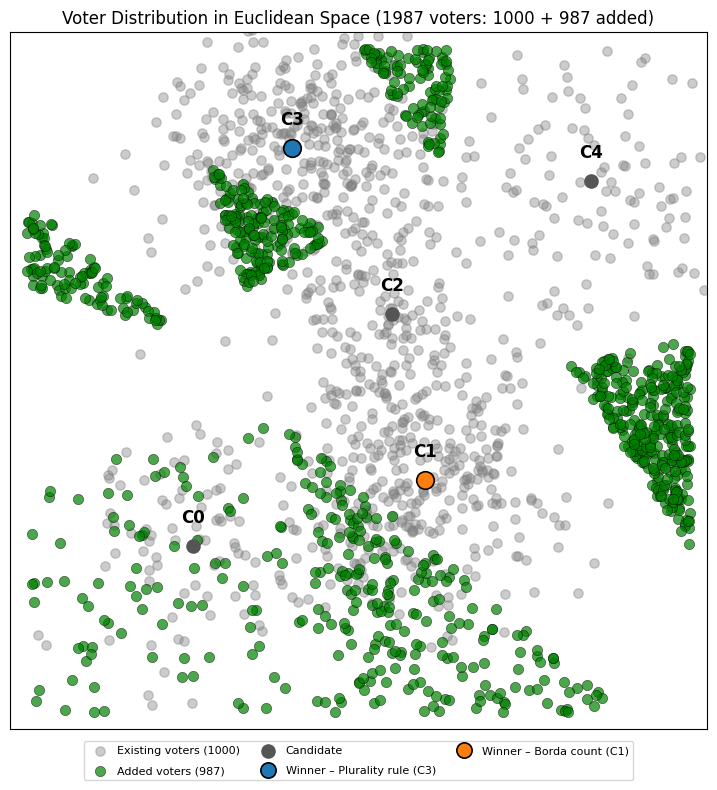

existing: 1000, added: 987

rule          target  actual   margin
plurality          3       3        1
borda              1       1        4


In [8]:
_ = run_swap(winners, objective="minmax")  # keep the fullest region as small as possible

target {'plurality': 3, 'borda': 1}, objective 'maxmin' -> Optimal


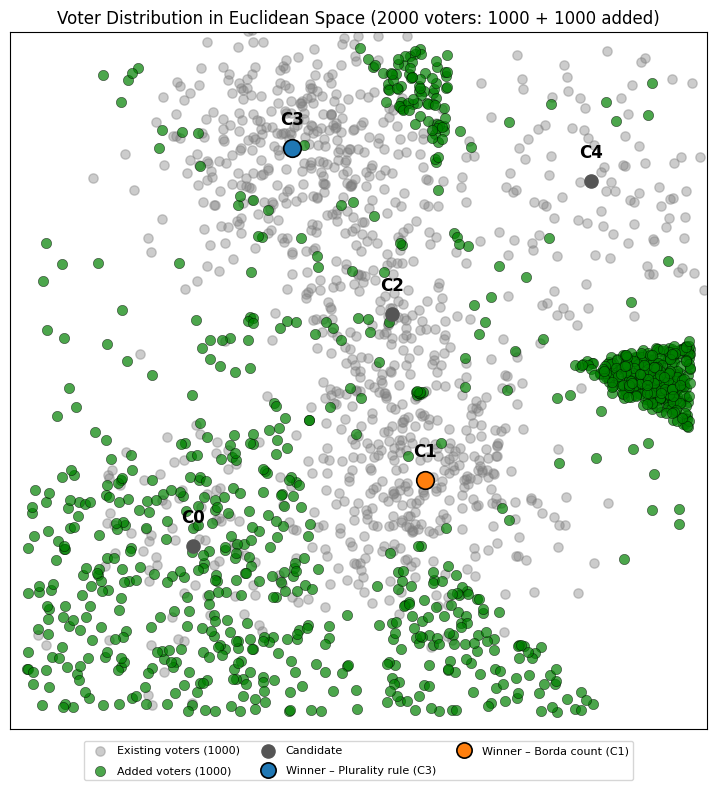

existing: 1000, added: 1000

rule          target  actual   margin
plurality          3       3        1
borda              1       1        1


In [9]:
_ = run_swap(winners, objective="maxmin")  # lift the emptiest region

target {'plurality': 3, 'borda': 1}, objective 'range' -> Optimal


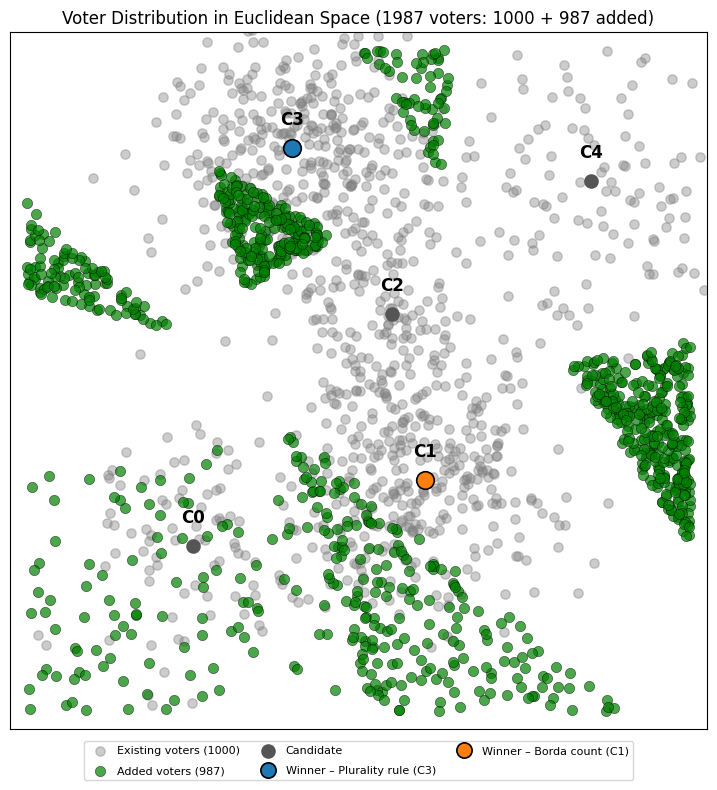

existing: 1000, added: 987

rule          target  actual   margin
plurality          3       3        1
borda              1       1        4


In [10]:
_ = run_swap(winners, objective="range")  # squeeze the gap between fullest and emptiest

target {'plurality': 3, 'borda': 1}, objective 'min_total' -> Optimal


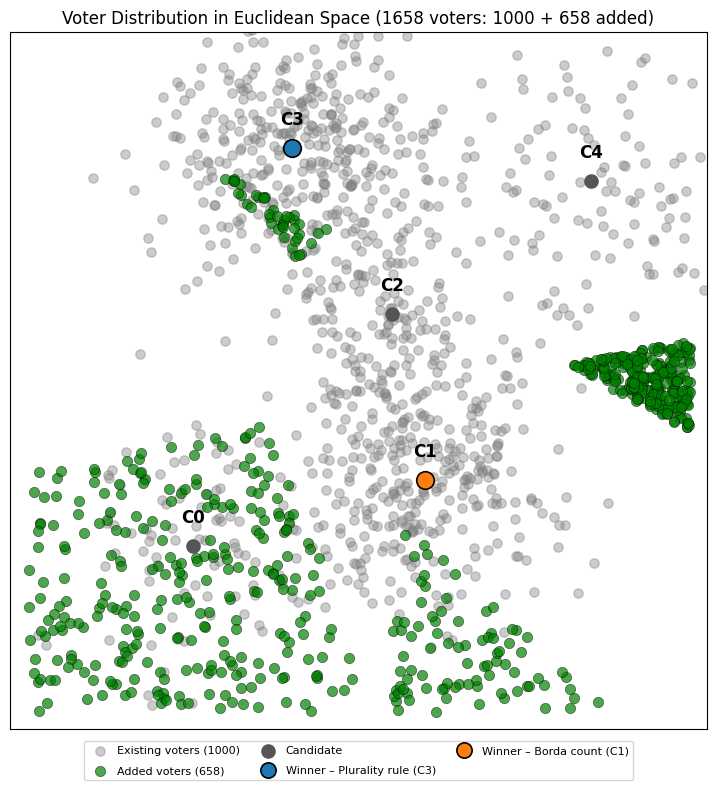

existing: 1000, added: 658

rule          target  actual   margin
plurality          3       3        1
borda              1       1        1


In [11]:
_ = run_swap(winners, objective="min_total")  # add as few voters as possible - the price of this outcome

## Every outcome this electorate can be talked into

Each of the `N_CANDIDATES ** len(RULES)` winner assignments gets priced by the
same model under `min_total`. The ones that come back `Infeasible` are not
expensive - they are unreachable, because no arrangement of points in the plane
produces them at all.

In [12]:
def reachable_outcomes(model, rules):
    """Price every winner assignment except the one the electorate already gives.

    Returns ``(natural, reachable, unreachable)``, where ``reachable`` is a list
    of ``(combo, voters added)`` sorted cheapest first.
    """
    keys = [rule.key for rule in rules]
    natural = tuple(
        Election(model.candidates, model.voters).compare(rules).winner_index(rule)
        for rule in rules
    )
    original = model.winners

    reachable, unreachable = [], []
    for combo in product(range(model.n_candidates), repeat=len(keys)):
        if combo == natural:
            continue
        model.winners = dict(zip(keys, combo))
        model.build()
        if model.solve() != "Optimal":
            unreachable.append(combo)
            continue
        reachable.append((combo, sum(model.solution_counts().values())))

    reachable.sort(key=lambda row: row[1])

    model.winners = original  # hand the model back as it was given
    model.build()
    return natural, reachable, unreachable

In [13]:
# The region pool depends only on the candidates, never on the target, so one
# model is built and reused across every combination - only `winners` changes.
search_model = LpModel(
    candidates=candidates,
    base_voters=voters,
    max_added=N_VOTERS * 2,  # loose enough not to distort the price
    winners={},
    objective="min_total",
    pool_size=100_000,
)
_ = search_model.regions  # sample the pool once

natural, reachable, unreachable = reachable_outcomes(search_model, RULES)
total = len(reachable) + len(unreachable)

print(f"natural outcome: {natural}")
print(f"reachable: {len(reachable)}/{total}, unreachable: {len(unreachable)}/{total}")

natural outcome: (3, 2)
reachable: 20/24, unreachable: 4/24


## The cheapest change of mind

cheapest flip: (1, 2) costs 45 added voters

target {'plurality': 1, 'borda': 2}, objective 'min_total' -> Optimal


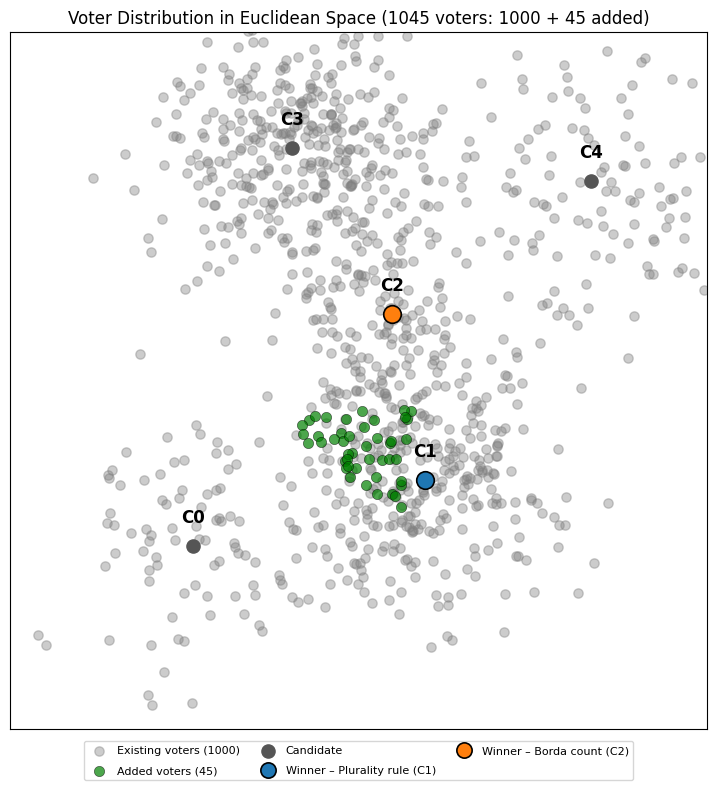

existing: 1000, added: 45

rule          target  actual   margin
plurality          1       1        1
borda              2       2      612


In [14]:
target_combo, n_added = reachable[0]
print(f"cheapest flip: {target_combo} costs {n_added} added voters")
print()

_ = run_swap(target_combo, max_added=N_VOTERS * 2)

## Which changes pull the winners apart?

Price says what is cheap; the project's own measure says what is interesting.
`mean_pairwise_distance` is the quantity 01 and 02 histogram, so an outcome
scoring above the natural one is a case where buying voters made the rules
disagree more sharply than they already did.

In [15]:
candidate_positions = np.array([c.position for c in candidates], dtype=float)


def winner_spread(combo):
    """Mean pairwise distance between the winning candidates, as in 01 and 02."""
    return mean_pairwise_distance([candidate_positions[i] for i in combo])

natural outcome (3, 2): spread = 5.83

most-dispersed reachable outcomes (* = wider than natural):
  (0, 3): spread=12.37, add  678 voters *
  (3, 0): spread=12.37, add 1177 voters *
  (3, 1): spread=10.77, add  658 voters *
  (1, 3): spread=10.77, add 1158 voters *
  (4, 1): spread=10.30, add  497 voters *
  (1, 4): spread=10.30, add 1000 voters *
  (0, 2): spread= 9.22, add  232 voters *
  (4, 3): spread= 9.06, add  673 voters *
  (3, 4): spread= 9.06, add  985 voters *
  (0, 1): spread= 7.28, add  502 voters *

target {'plurality': 0, 'borda': 3}, objective 'min_total' -> Optimal


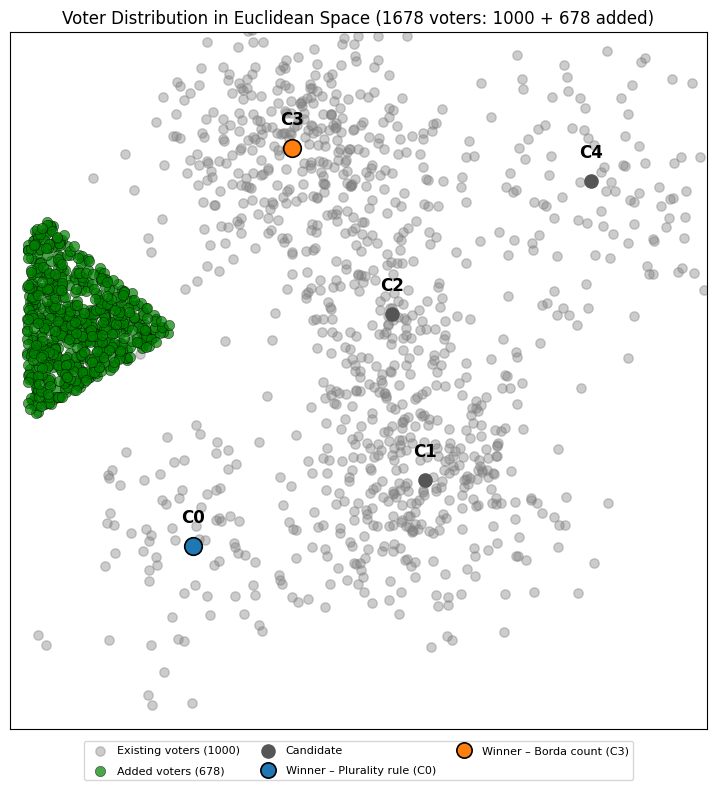

existing: 1000, added: 678

rule          target  actual   margin
plurality          0       0        1
borda              3       3        1


In [16]:
base_spread = winner_spread(natural)
print(f"natural outcome {natural}: spread = {base_spread:.2f}")
print()

# Most dispersed first, ties broken by the cheaper option.
ranked = sorted(reachable, key=lambda row: (-winner_spread(row[0]), row[1]))
print("most-dispersed reachable outcomes (* = wider than natural):")
for combo, added in ranked[:10]:
    spread = winner_spread(combo)
    flag = " *" if spread > base_spread else ""
    print(f"  {combo}: spread={spread:5.2f}, add {added:>4} voters{flag}")

best_combo, _ = ranked[0]
print()
_ = run_swap(best_combo, max_added=N_VOTERS * 2)

## All of them at once

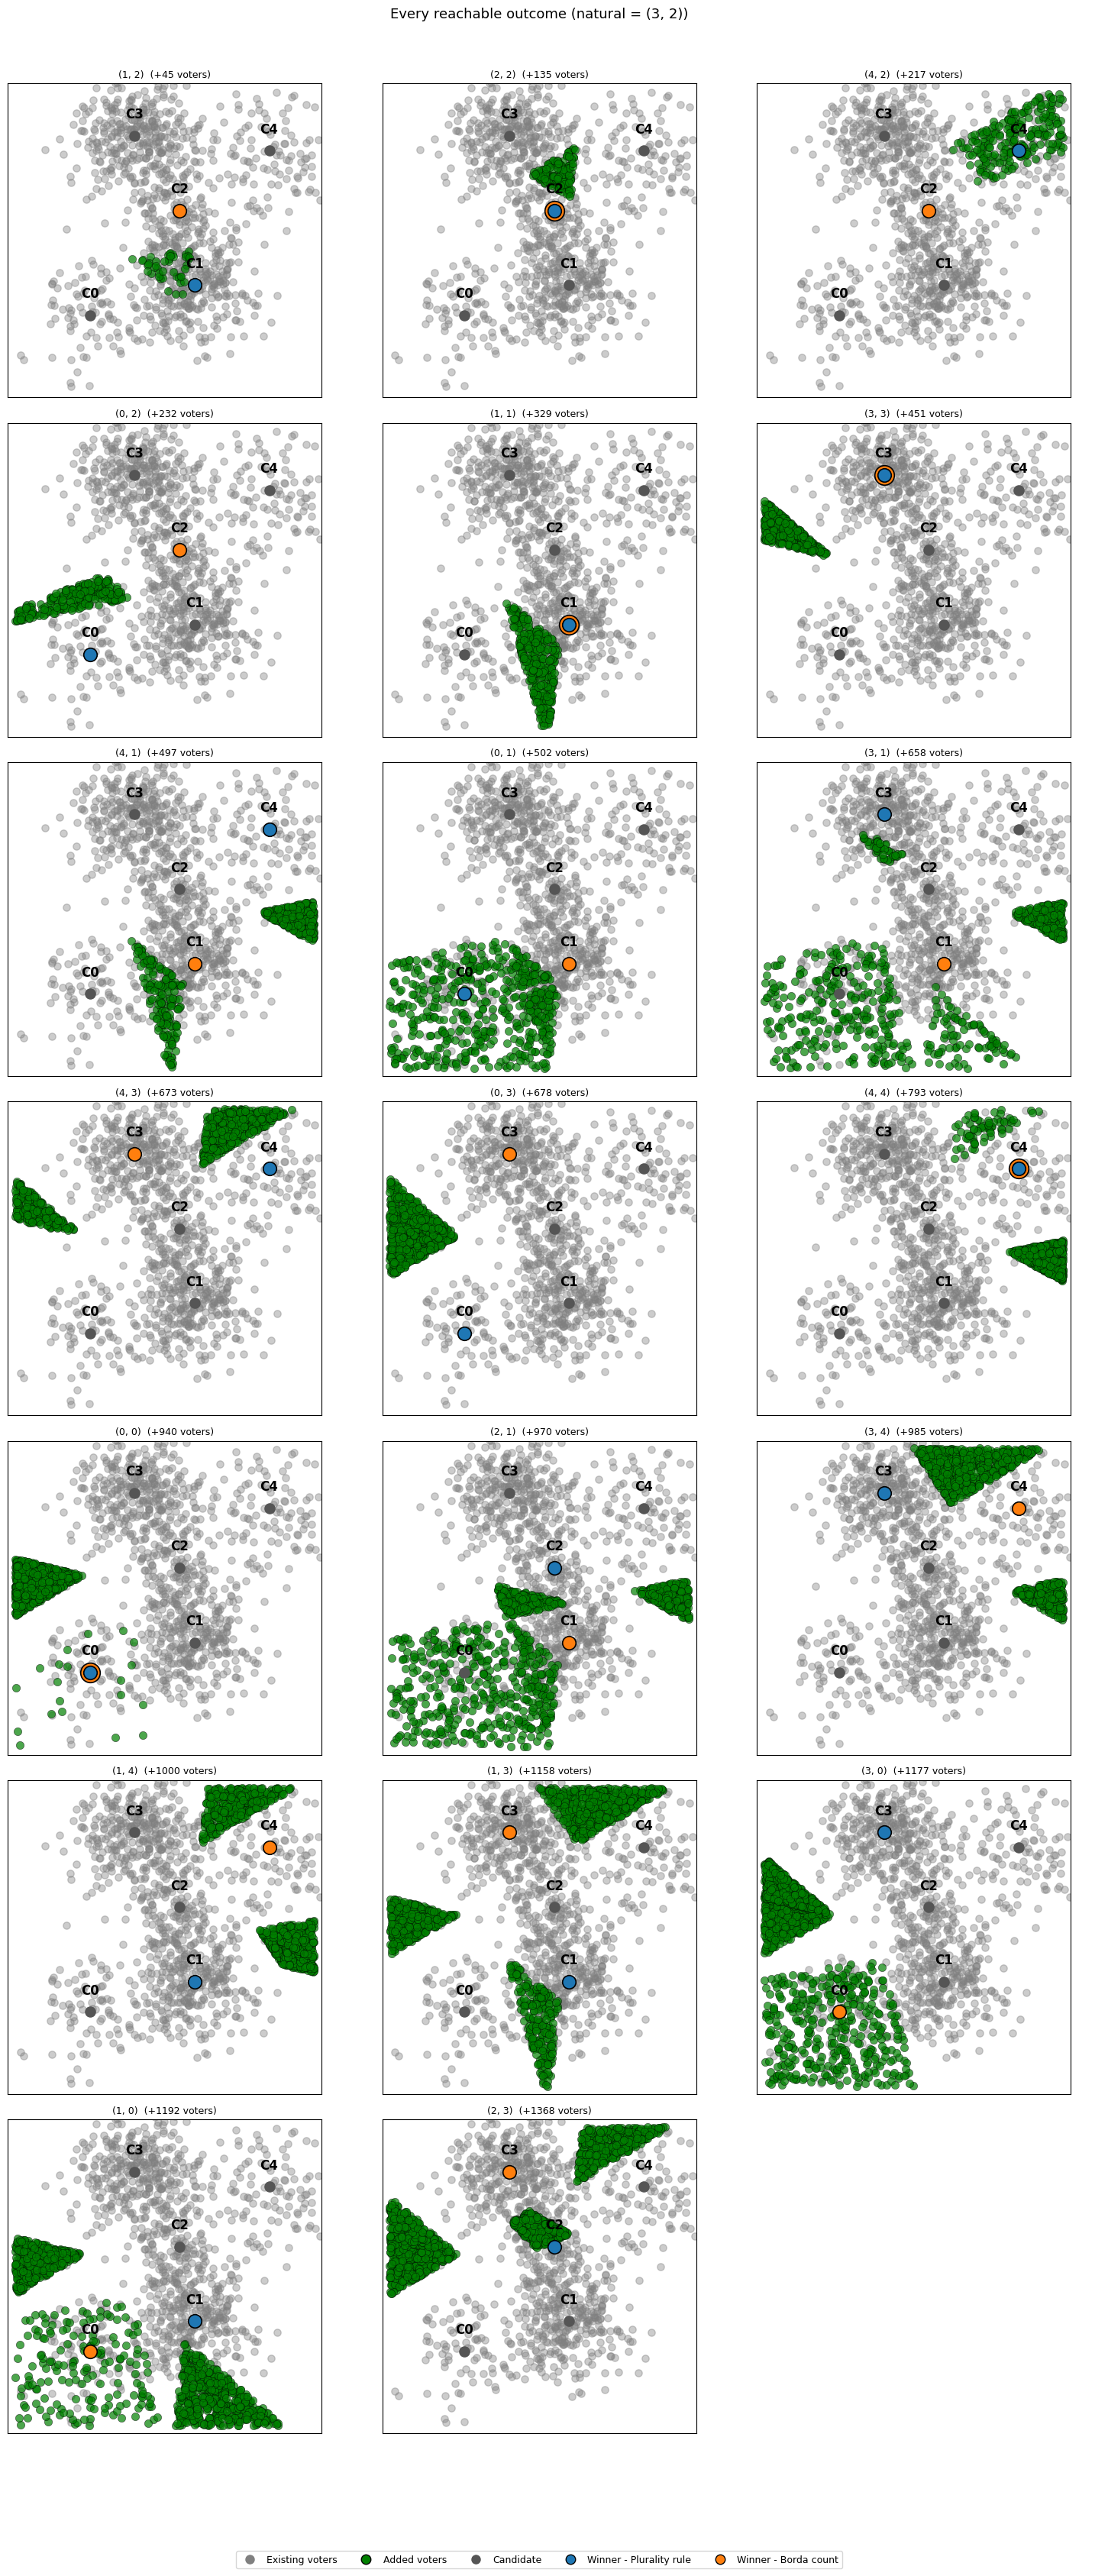

In [17]:
existing = np.array([v.position for v in voters])

ncols = 3
nrows = -(-len(reachable) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.8))
axes = np.atleast_1d(axes).ravel()

for ax, (combo, added_count) in zip(axes, reachable):
    search_model.winners = dict(zip(RULES, combo))
    search_model.build()
    search_model.solve()
    plot_election(
        candidates,
        existing,
        search_model.winners,
        added_voters=search_model.generate_voter_positions(),
        ax=ax,
        legend=False,
    )
    ax.set_title(f"{combo}  (+{added_count} voters)", fontsize=9)

for ax in axes[len(reachable):]:
    ax.axis("off")


def legend_dot(color, label, edge="black"):
    return Line2D(
        [], [], marker="o", linestyle="None", markerfacecolor=color,
        markeredgecolor=edge, markersize=9, label=label,
    )


palette = plt.cm.tab10.colors
shared = [
    legend_dot("gray", "Existing voters", edge="none"),
    legend_dot("green", "Added voters"),
    legend_dot("#555555", "Candidate", edge="none"),
] + [
    legend_dot(palette[i % len(palette)], f"Winner - {rule.name}")
    for i, rule in enumerate(RULES)
]

fig.suptitle(f"Every reachable outcome (natural = {natural})", fontsize=13)
fig.legend(
    handles=shared, loc="lower center", ncols=len(shared), fontsize=9,
    bbox_to_anchor=(0.5, -0.02),
)
fig.tight_layout(rect=(0, 0.03, 1, 0.97))
plt.show()